# 1. Bradley-Terry Model with Home Court Advantage

### Imports

In [30]:
import pandas as pd
import numpy as np
import json
from typing import Dict, List, Tuple, Optional
from datetime import datetime

import choix
from scipy.special import expit
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, average_precision_score,brier_score_loss, precision_recall_fscore_support, confusion_matrix, precision_score, ConfusionMatrixDisplay,f1_score,recall_score
import seaborn as sns
from scipy.stats import norm
from scipy.stats import beta as beta_dist
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt import gp_minimize
from skopt.plots import plot_convergence, plot_objective
from skopt.space import Real
from skopt.utils import use_named_args
import plotly.express as px
import plotly.graph_objects as go

### Bradley–Terry Model with HCA & Covariates

In [31]:
class BTWithCovariates:
    def __init__(
        self,
        teams, team_to_idx,
        s, beta,
        feature_cols, mu, sd,
        context_cols=None, gamma=None,
        mu_context=None, sd_context=None,
        lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3,
        threshold=0.5,alpha_hca=None
    ):
        # --- core team parameters ---
        self.teams = list(teams)
        self.team_to_idx = dict(team_to_idx)
        self.s = np.array(s, dtype=float)
        self.s -= self.s.mean()  # mean‑centering for identifiability
        self.alpha_hca = 0.1 if alpha_hca is None else float(alpha_hca)

        # --- feature-related parameters X@beta ---
        self.feature_cols = list(feature_cols)
        self.beta = np.array(beta, dtype=float)
        self.mu = np.array(mu, dtype=float)
        self.sd = np.array(sd, dtype=float)
        self.sd[self.sd == 0] = 1.0

        # --- contextual HCA parameters Z@gamma ---
        self.context_cols = list(context_cols) if context_cols else []
        self.gamma = (
            np.random.normal(0, 0.01, len(self.context_cols))
            if gamma is None
            else np.array(gamma, dtype=float)
        )
        self.mu_context = (
            np.zeros(len(self.context_cols))
            if mu_context is None
            else np.array(mu_context, dtype=float)
        )
        self.sd_context = (
            np.ones(len(self.context_cols))
            if sd_context is None
            else np.array(sd_context, dtype=float)
        )
        self.sd_context[self.sd_context == 0] = 1.0

        # learning configuration
        self.lambda_s, self.lambda_b, self.lambda_g = lambda_s, lambda_b, lambda_g
        self.threshold = threshold

    # ---------------- Properties ----------------
    @property
    def m(self): return len(self.teams)
    @property
    def p(self): return len(self.feature_cols)
    @property
    def q(self): return len(self.context_cols)

    # ---------------- Utilities ----------------
    def _ensure_teams(self, df: pd.DataFrame):
        """Ensure unseen teams get added dynamically."""
        unseen = [t for t in pd.unique(df[["home_abbr", "away_abbr"]].values.ravel())
                  if t not in self.team_to_idx]
        if not unseen:
            return
        start = len(self.teams)
        for k, t in enumerate(unseen):
            self.team_to_idx[t] = start + k
        self.teams.extend(unseen)
        # Expand s for new teams (neutral start)
        self.s = np.concatenate([self.s, np.zeros(len(unseen))])
        self.s -= self.s.mean()

    def _standardize(self, arr, mu, sd):
        return (arr - mu) / (sd if sd != 0 else 1.0)

    def _standardize_features(self, frame):
        if self.p == 0:
            return np.zeros((len(frame), 0))
        X = np.zeros((len(frame), self.p))
        for j, col in enumerate(self.feature_cols):
            X[:, j] = self._standardize(frame[col].astype(float).values, self.mu[j], self.sd[j])
        return X

    def _standardize_context(self, frame):
        if self.q == 0:
            return np.zeros((len(frame), 0))
        Z = np.zeros((len(frame), self.q))
        for j, col in enumerate(self.context_cols):
            Z[:, j] = self._standardize(
                frame[col].astype(float).values, self.mu_context[j], self.sd_context[j]
            )
        return Z

    # ---------------- Prediction ----------------
    def predict_proba(self, frame: pd.DataFrame) -> np.ndarray:
        sh = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["home_abbr"]])
        sa = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["away_abbr"]])

        z = (sh - sa) + self.alpha_hca

        if self.q:
            Z = self._standardize_context(frame)
            z += Z @ self.gamma
        if self.p:
            X = self._standardize_features(frame)
            z += X @ self.beta

        # apply sigmoid
        p = 1.0 / (1.0 + np.exp(-z))
        return p

    def predict_class(self, frame: pd.DataFrame, threshold=None) -> np.ndarray:
        threshold = self.threshold if threshold is None else threshold
        return (self.predict_proba(frame) >= threshold).astype(int)

    # ---------------- Evaluation ----------------
    def evaluate(self, frame: pd.DataFrame, threshold=None):
        threshold = self.threshold if threshold is None else threshold
        p = self.predict_proba(frame)
        y_true = frame["home_win"].astype(int).values
        yhat = (p >= threshold).astype(int)
        acc = (yhat == y_true).mean()
        logloss = -(y_true * np.log(p + 1e-12)
                    + (1 - y_true) * np.log(1 - p + 1e-12)).mean()
        return acc, logloss


    def _mm_update_s(self, home_idx, away_idx, y, X, Z, beta, gamma, mm_iter=5):
            """Perform MM updates for team strengths s while holding beta,gamma fixed."""
            m = self.m
            s = self.s.copy()
            for _ in range(mm_iter):
                exp_s = np.exp(s)
                num = np.zeros(m)
                denom = np.zeros(m)

                for i in range(len(y)):
                    h, a = home_idx[i], away_idx[i]
                    eta = 0.0
                    if X.shape[1]:
                        eta += X[i] @ beta
                    if Z.shape[1]:
                        eta += Z[i] @ gamma
                    p_hat = 1.0 / (1.0 + np.exp(-(s[h] - s[a] + eta)))

                    # Accumulate numerators/denominators
                    num[h] += y[i]
                    num[a] += 1.0 - y[i]
                    denom[h] += p_hat
                    denom[a] += 1.0 - p_hat

                s = np.log((num + 1e-12) / (denom + 1e-12))
                s -= s.mean()   # identifiability
            return s

    def fit(self, df, split_col=None, split_value=None,
            valid_frame=None, test_frame=None, max_iter=1000,
            mm_iter=5, verbose=1):

        data = df if split_col is None else df[df[split_col] == split_value]
        if len(data) == 0:
            raise ValueError("Empty training data.")

        self._ensure_teams(data)

        home_idx = np.array([self.team_to_idx[t] for t in data["home_abbr"]], int)
        away_idx = np.array([self.team_to_idx[t] for t in data["away_abbr"]], int)
        y = data["home_win"].astype(float).values
        X = self._standardize_features(data)
        Z = self._standardize_context(data)
        m, p, q = self.m, self.p, self.q

        # ---------- Step 1: MM update for s (given current beta,gamma) ----------
        if verbose:
            print(f"Running {mm_iter} MM iterations for initial team strength update...")
        self.s = self._mm_update_s(home_idx, away_idx, y, X, Z,
                                   self.beta.copy(), self.gamma.copy(),
                                   mm_iter=mm_iter)

        # ---------- Step 2: Define joint objective for L‑BFGS ----------
        def objective(x):
            s = x[:m]; b = x[m:m+p]; g = x[m+p:m+p+q]; a = x[-1]
            z = (s[home_idx] - s[away_idx]) + a
            if p: z += X @ b
            if q: z += Z @ g
            p_hat = 1 / (1 + np.exp(-z))
            nll = -np.sum(y * np.log(p_hat + 1e-12) +
                          (1 - y) * np.log(1 - p_hat + 1e-12))
            reg = 0.5 * (self.lambda_s*np.sum(s**2)
                         + self.lambda_b*np.sum(b**2)
                         + self.lambda_g*np.sum(g**2)
                         + 1e-4 * a**2)
            loss = nll + reg

            err = y - p_hat
            grad_s = np.zeros_like(s)
            np.add.at(grad_s, home_idx, -err)
            np.add.at(grad_s, away_idx, err)
            grad_b = -(X.T @ err) if p else np.zeros(0)
            grad_g = -(Z.T @ err) if q else np.zeros(0)
            grad_a = -np.sum(err) + 1e-4*a
            grad = np.concatenate([grad_s, grad_b, grad_g, [grad_a]])
            return loss, grad

        # ---------- Step 3: History tracking ----------
        history = {"iter": [], "train_acc": [], "train_logloss": [],
                   "test_acc": [],  "test_logloss": []}

        def callback(xk):
            if verbose is None:
                return
            it = len(history["iter"])
            if it % verbose == 0:
                self.s = xk[:m]
                self.beta = xk[m:m+p]
                self.gamma = xk[m+p:m+p+q]
                self.s -= self.s.mean()
                tr_acc, tr_ll = self.evaluate(data)
                te_acc, te_ll = (np.nan, np.nan)
                if test_frame is not None:
                    te_acc, te_ll = self.evaluate(test_frame)
                history["iter"].append(it)
                history["train_acc"].append(tr_acc)
                history["train_logloss"].append(tr_ll)
                history["test_acc"].append(te_acc)
                history["test_logloss"].append(te_ll)
                print(f"[{it:04d}] Train acc={tr_acc:.4f} ll={tr_ll:.4f} | "
                      f"Test acc={te_acc:.4f} ll={te_ll:.4f}")

        # ---------- L‑BFGS Optimization ----------
        x0 = np.concatenate([self.s, self.beta, self.gamma, [self.alpha_hca]])
        res = minimize(
            objective, x0, jac=True, method="L-BFGS-B",
            callback=callback,
            options={"disp": True, "maxiter": max_iter}
        )

        # ---------- Post‑process ----------
        opt = res.x
        self.s = opt[:m]
        self.beta = opt[m:m+p]
        self.gamma = opt[m+p:m+p+q]
        self.alpha_hca = opt[-1]
        self.s -= self.s.mean()

        tr_acc, tr_ll = self.evaluate(data)
        te_acc, te_ll = (np.nan, np.nan)
        if test_frame is not None:
            te_acc, te_ll = self.evaluate(test_frame)

        history["iter"].append(len(history["iter"]))
        history["train_acc"].append(tr_acc)
        history["train_logloss"].append(tr_ll)
        history["test_acc"].append(te_acc)
        history["test_logloss"].append(te_ll)

        avg_theta = np.exp(self.alpha_hca + np.mean(Z @ self.gamma))
        print(f"Estimated global home‑court multiplier θ̄ = {avg_theta:.4f}")
        if verbose:
            print(f"Final: Train acc={tr_acc:.4f}, logloss={tr_ll:.4f}")

        return {"opt_result": res, "history": history}

### Load and Save Model

In [32]:
def save_model(
    model,
    path_npz: str,
    path_json: Optional[str] = None,
    extra_meta: Optional[Dict] = None,
):
    """
    Save a trained BTWithCovariates model to a compressed .npz file.
    Optionally dump a human-readable JSON alongside it.

    Parameters
    ----------
    model : BTWithCovariates
        Trained model instance.
    path_npz : str
        Path to the output compressed NumPy file (.npz).
    path_json : str, optional
        Path to a JSON file for human-readable parameters.
    extra_meta : dict, optional
        Extra information to store in metadata.
    """
    # --- Prepare metadata ---
    meta = {
        "feature_cols": model.feature_cols,
        "teams": model.teams,
        "extra_meta": extra_meta or {},
        "class_name": model.__class__.__name__,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "optimizer_settings": {
            "lambda_s": model.lambda_s, "lambda_b": model.lambda_b,"threshold": model.threshold,
        },
    }

    # --- Save the model core parameters ---
    np.savez_compressed(
        path_npz,
        s=np.array(model.s, dtype=float),
        beta=np.array(model.beta, dtype=float),
        mu=np.array(model.mu, dtype=float),
        sd=np.array(model.sd, dtype=float),
        teams=np.array(model.teams, dtype=object),
        t2i_keys=np.array(list(model.team_to_idx.keys()), dtype=object),
        t2i_vals=np.array(list(model.team_to_idx.values()), dtype=int),
        gamma=np.array(getattr(model, "gamma", []), dtype=float),
        mu_context=np.array(getattr(model, "mu_context", []), dtype=float),
        sd_context=np.array(getattr(model, "sd_context", []), dtype=float),
        context_cols=np.array(getattr(model, "context_cols", []), dtype=object),
        meta_json=np.bytes_(json.dumps(meta)),
    )

    # --- Optional JSON dump for readability ---
    if path_json:
        payload = {
            "s": model.s.tolist(),
            "beta": model.beta.tolist(),
            "mu": np.array(model.mu).tolist(),
            "sd": np.array(model.sd).tolist(),
            "teams": model.teams,
            "team_to_idx": model.team_to_idx,
            "extra_meta": meta["extra_meta"],
            "optimizer_settings": meta["optimizer_settings"],
            "timestamp": meta["timestamp"],
        }
        with open(path_json, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        print(f"Model parameters saved to {path_json}")

    print(f"Model saved successfully to {path_npz}")

def load_model(path_npz: str) -> BTWithCovariates:
    """
    Load a saved BTWithCovariates model (.npz) and reconstruct it
    ready for predictions or continued training on a new dataset.
    """
    # --- Load the compressed file ---
    blob = np.load(path_npz, allow_pickle=True)

    # --- Basic parameters ---
    s = blob["s"].astype(float)

    beta = blob["beta"].astype(float)
    mu = blob["mu"].astype(float)
    sd = blob["sd"].astype(float)
    teams = list(blob["teams"])
    t2i_keys = list(blob["t2i_keys"])
    t2i_vals = list(blob["t2i_vals"])
    team_to_idx = {k: int(v) for k, v in zip(t2i_keys, t2i_vals)}

    # --- Retrieve metadata ---
    meta_raw = blob["meta_json"].tobytes().decode("utf-8")
    meta = json.loads(meta_raw)
    feature_cols = meta.get("feature_cols", [])
    optimizer_settings = meta.get("optimizer_settings", {})

    # --- Restore training hyperparameters safely ---
    lambda_s = float(optimizer_settings.get("lambda_s", 0.002))
    lambda_b = float(optimizer_settings.get("lambda_b", 0.01))
    threshold = float(optimizer_settings.get("threshold", 0.5))
    decay_every = optimizer_settings.get("decay_every", None)
    decay_factor = optimizer_settings.get("decay_factor", None)
    gamma = blob.get("gamma")
    if gamma is not None: gamma = gamma.astype(float)
    mu_context = blob.get("mu_context")
    if mu_context is not None: mu_context = mu_context.astype(float)
    sd_context = blob.get("sd_context")
    if sd_context is not None: sd_context = sd_context.astype(float)
    context_cols = list(blob.get("context_cols", []))

    # --- Recreate model instance ---
    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s,
        beta=beta,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        threshold=threshold,
        gamma=gamma,
        context_cols=context_cols,
        mu_context=mu_context,
        sd_context=sd_context,
    )

    print(f"Model loaded successfully from {path_npz}")
    print(f"Teams: {len(teams)} | Features: {len(feature_cols)}")

    return model

### 1.2 Load Data & Initialization

In [33]:
df = pd.read_csv('./data/bt_games_cleaned.csv')
df=df[df["Game_Type"]=="regular"]
context_cols = ["home_b2b", "away_b2b","home_rest_days", "away_rest_days", "rest_diff"]
feature_cols = ["diff_recent_margin","diff_recent_win_pct","diff_pts_pg_to_date","split_win_pct_delta"]

train=df[df["split"]=="train"].copy()
test=df[df["split"]=="test"].copy()

### 1.3 Build Train Tensors

In [34]:
# Extract indices
teams = sorted(pd.unique(pd.concat([train["home_abbr"], train["away_abbr"]], ignore_index=True)))
team_to_idx = {t: i for i, t in enumerate(teams)}
m = len(teams)

home_idx = np.array([team_to_idx[t] for t in train["home_abbr"]], dtype=int)
away_idx = np.array([team_to_idx[t] for t in train["away_abbr"]], dtype=int)
y = train["home_win"].astype(float).values
n = len(y)

# Standardize regular feature columns (X)
if feature_cols:
    X_raw = train[feature_cols].astype(float).values
    mu = X_raw.mean(axis=0)
    sd = X_raw.std(axis=0)
    sd[sd == 0] = 1.0
    X = (X_raw - mu) / sd
else:
    X = np.zeros((n, 0))
    mu = np.array([])
    sd = np.array([])
p = X.shape[1]

# Standardize contextual columns (Z)
if context_cols:
    Z_raw = train[context_cols].astype(float).values
    mu_context = Z_raw.mean(axis=0)
    sd_context = Z_raw.std(axis=0)
    sd_context[sd_context == 0] = 1.0
    Z = (Z_raw - mu_context) / sd_context
else:
    Z = np.zeros((n, 0))
    mu_context = np.array([])
    sd_context = np.array([])
q = Z.shape[1]

In [35]:
s_init     = np.zeros(len(teams))
beta_init  = np.zeros(len(feature_cols))
gamma_init = np.zeros(len(context_cols))

## 1.A Train and Test

### 1.4 Model Fitting

In [36]:
# After creating df with split in {"train","test","valid"} and computing mu/sd on TRAIN
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu, sd=sd,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context,
    lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3
)

result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    test_frame=test,
    verbose=1
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6260 ll=0.6520
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6241 ll=0.6507
[0003] Train acc=0.6536 ll=0.6247 | Test acc=0.6290 ll=0.6502
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6279 ll=0.6504
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6244 ll=0.6515
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6195 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6203 ll=0.6533
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6211 ll=0.6534
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0015] Tra

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



### 1.5 Result Evaluation

In [37]:
def evaluate_metrics(model, frame, threshold=0.5, eps=1e-12):
    y_true = frame["home_win"].astype(int).values
    p = model.predict_proba(frame)

    # Core metrics
    acc = accuracy_score(y_true, (p >= threshold).astype(int))
    ll = log_loss(y_true, np.clip(p, eps, 1 - eps))
    brier = brier_score_loss(y_true, p)

    # Ranking metrics (guard against edge cases)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan

    # Threshold metrics
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, (p >= threshold).astype(int), average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, (p >= threshold).astype(int)).ravel()

    return {
        "n": int(len(y_true)),
        "accuracy": float(acc),
        "log_loss": float(ll),
        "brier": float(brier),
        "roc_auc": float(auc),
        "avg_precision": float(ap),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [38]:
train_metrics = evaluate_metrics(model, train)
test_metrics  = evaluate_metrics(model, test)

print("Train metrics:")
for k, v in train_metrics.items():
    print(f"  {k}: {v}")

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Train metrics:
  n: 8289
  accuracy: 0.6554469779225479
  log_loss: 0.61713329096084
  brier: 0.2141391665098322
  roc_auc: 0.7049108378210907
  avg_precision: 0.7502822969047198
  precision: 0.6740361775991229
  recall: 0.7748372190716236
  f1: 0.7209302325581395
  tn: 1744
  fp: 1784
  fn: 1072
  tp: 3689
Test metrics:
  n: 3690
  accuracy: 0.6292682926829268
  log_loss: 0.6510608181932706
  brier: 0.2290433937794981
  roc_auc: 0.6607413934303094
  avg_precision: 0.6901754642150071
  precision: 0.6372036962635597
  recall: 0.7732813261823501
  f1: 0.6986784140969163
  tn: 736
  fp: 903
  fn: 465
  tp: 1586


### 1.6 Plots

In [39]:
hist = result["history"]

# convert arrays safely
iters     = np.array(hist["iter"], dtype=float)
train_acc = np.array(hist["train_acc"], dtype=float)
test_acc  = np.array(hist["test_acc"], dtype=float)
train_ll  = np.array(hist["train_logloss"], dtype=float)
test_ll   = np.array(hist["test_logloss"], dtype=float)

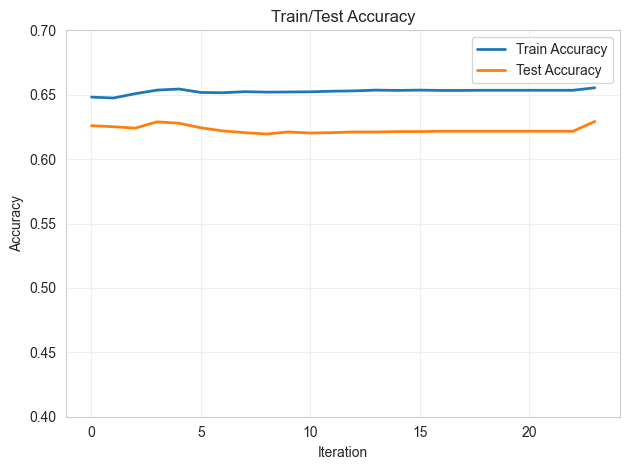

In [40]:
# --- Accuracy plot ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

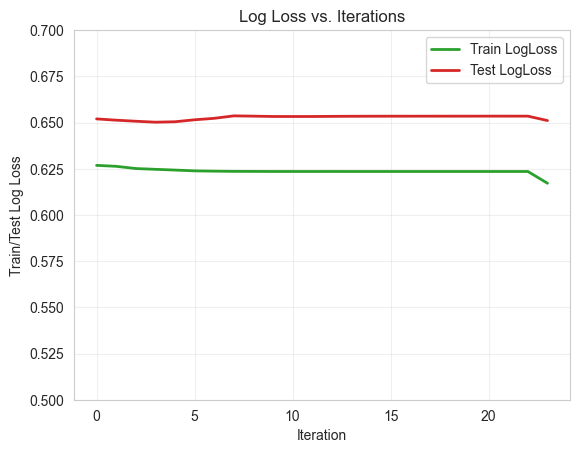

In [41]:
# Log-loss
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.5, 0.7)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [42]:
def calibration_curve_with_ci(y_true, p_pred, n_bins=10, strategy="uniform", title="Calibration Curve (Reliability Diagram)"):
    """
    Plots calibration curve with 95% binomial CIs for each bin.
    y_true: array-like of shape (n_samples,), values in {0,1}
    p_pred: array-like of predicted probabilities in [0,1]
    n_bins: number of bins
    strategy: "uniform" (equal-width in probability) or "quantile" (equal-count)
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    df = pd.DataFrame({"y": y_true, "p": p_pred})

    if strategy == "quantile":
        # Bin by quantiles of predicted probability (equal count)
        # Ensure unique bin edges
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(df["p"], quantiles))
        # If many ties shrink number of bins
        if len(edges) - 1 < n_bins:
            n_bins = len(edges) - 1
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True, duplicates="drop")
    elif strategy == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True)
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")

    grp = df.groupby("bin", observed=False)
    n = grp.size().values
    if len(n) == 0:
        raise ValueError("No bins formed. Check inputs.")

    p_mean = grp["p"].mean().values
    y_mean = grp["y"].mean().values  # observed frequency
    # 95% binomial proportion CI using Wilson or Beta posterior (Jeffreys)
    # Here: Jeffreys interval via Beta(0.5,0.5) posterior for robustness in small bins.
    k = (grp["y"].sum()).values
    lower = beta_dist.ppf(0.025, k + 0.5, n - k + 0.5)
    upper = beta_dist.ppf(0.975, k + 0.5, n - k + 0.5)

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
    ax.errorbar(p_mean, y_mean, yerr=[y_mean - lower, upper - y_mean],
                fmt="o", color="#1f77b4", ecolor="#1f77b4", elinewidth=1, capsize=3, label="Bins")
    # Bin sizes as marker size
    ms = 20 * (n / n.max())
    ax.scatter(p_mean, y_mean, s=ms, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title + f"\n(n={len(y_true)}, bins={n_bins}, strategy={strategy})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

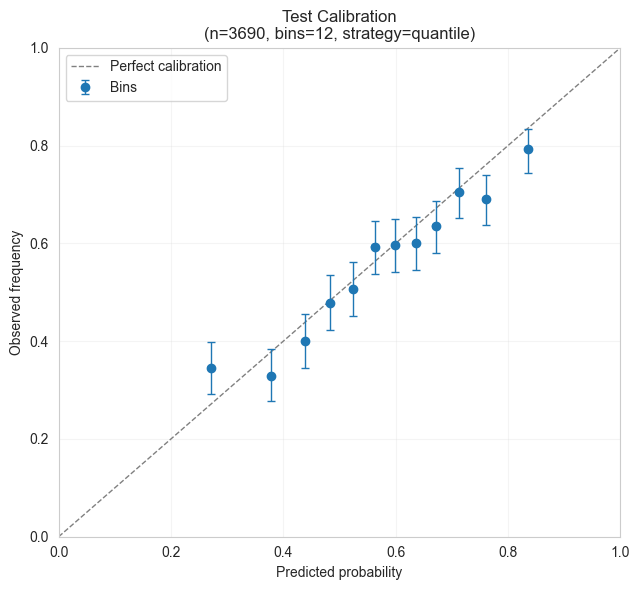

In [43]:
y_true_test = test['home_win'].astype(int).values
p_pred_test = model.predict_proba(test)
calibration_curve_with_ci(y_true_test, p_pred_test, n_bins=12, strategy="quantile", title="Test Calibration")

In [44]:
def normal_probability_plot_with_band(y_true, p_pred, n_sim=500, title="Normal Probability Plot of Standardized Residuals"):
    """
    Creates a Q–Q plot for standardized probability residuals r = (y - p) / sqrt(p(1-p)),
    with a 95% simulation band that accounts for heteroskedastic Bernoulli noise.
    The band is generated by parametric bootstrap under the fitted probabilities.
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    # Standardized residuals (Pearson residuals for Bernoulli)
    r = (y_true - p_pred) / np.sqrt(p_pred * (1 - p_pred))

    # Sort residuals and their theoretical normal quantiles
    r_sorted = np.sort(r)
    n = len(r_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    z_theory = norm.ppf(probs)

    # Simulation band: simulate y* ~ Bernoulli(p_pred), compute residuals, take order stats
    rng = np.random.default_rng(12345)
    sim_order_stats = np.empty((n_sim, n), dtype=float)
    for s in range(n_sim):
        y_sim = rng.binomial(1, p_pred)
        r_sim = (y_sim - p_pred) / np.sqrt(p_pred * (1 - p_pred))
        sim_order_stats[s, :] = np.sort(r_sim)

    lower = np.quantile(sim_order_stats, 0.025, axis=0)
    upper = np.quantile(sim_order_stats, 0.975, axis=0)

    # Plot
    fig, ax = plt.subplots(figsize=(6.8, 6.0))
    ax.fill_between(z_theory, lower, upper, color="#d3e5ff", alpha=0.8, label="95% simulation band")
    ax.plot(z_theory, r_sorted, "o", ms=3, color="#1f77b4", label="Empirical residuals")
    ax.plot([z_theory.min(), z_theory.max()], [z_theory.min(), z_theory.max()],
            "--", color="gray", lw=1, label="y=x")

    ax.set_xlabel("Theoretical quantiles N(0,1)")
    ax.set_ylabel("Ordered residuals")
    ax.set_title(title + f"\n(n={n})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

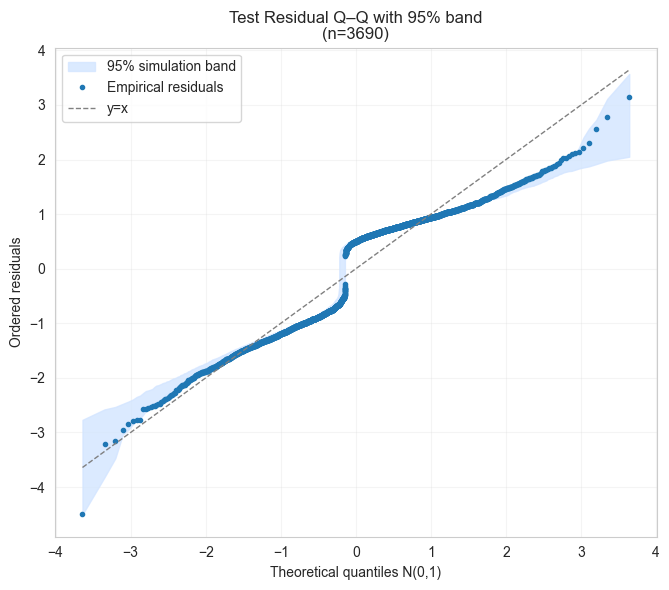

In [45]:
normal_probability_plot_with_band(y_true_test, p_pred_test, n_sim=800, title="Test Residual Q–Q with 95% band")

### 1.7 Optimization

### Method 1: Grid Search (Abandoned)

In [46]:
class BTWrapper(BaseEstimator, ClassifierMixin):
    """
    Minimal sklearn-compatible wrapper that uses BTWithCovariates *externally*.
    It does not modify your model; it just trains/evaluates it.
    """

    def __init__(self,
                 lambda_s=1e-3,
                 lambda_b=1e-3,
                 lambda_g=1e-3,
                 max_iter=800,
                 verbose=None):
        self.lambda_s = lambda_s
        self.lambda_b = lambda_b
        self.lambda_g = lambda_g
        self.max_iter = max_iter
        self.verbose = verbose


    def fit(self, X, y):
        # X must include all required columns (home_abbr, away_abbr, feature/context_cols)
        df_train = X.copy()
        df_train["home_win"] = y.astype(float)

        # Use closures for global game data and parameters already defined in your notebook
        global teams, team_to_idx, s_init, beta_init, feature_cols, mu, sd
        global context_cols, gamma_init, mu_context, sd_context

        self.model_ = BTWithCovariates(
            teams=teams,
            team_to_idx=team_to_idx,
            s=s_init.copy(),
            beta=beta_init.copy(),
            feature_cols=feature_cols,
            mu=mu, sd=sd,
            context_cols=context_cols,
            gamma=gamma_init.copy(),
            mu_context=mu_context, sd_context=sd_context,
            lambda_s=self.lambda_s,
            lambda_b=self.lambda_b,
            lambda_g=self.lambda_g,
            threshold=0.5,
        )

        self.model_.fit(
            df=df,
            split_col=None,
            max_iter=self.max_iter,
            verbose=self.verbose,
        )
        return self

    def predict(self, X):
        return self.model_.predict_class(X)

    def score(self, X, y):
        # Accuracy (used by GridSearchCV via scoring="accuracy")
        Xc = X.copy()
        Xc["home_win"] = y.astype(float)
        acc, _ = self.model_.evaluate(Xc)
        return acc


In [47]:
param_grid = {
    "lambda_s": np.logspace(-4, 4, 10),
    "lambda_b": np.logspace(-4, 1, 5),
    "lambda_g": np.logspace(-6, 1, 4),
}

X_train = df[df["split"] == "train"].drop(columns=["home_win", "split"])
y_train = df[df["split"] == "train"]["home_win"].astype(int)

X_test  = test.drop(columns=["home_win", "split"])
y_test  = test["home_win"].astype(int)

In [48]:
search = GridSearchCV(
    BTWrapper(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)
best_model = search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print("Test accuracy:", test_acc)

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Estimated global home‑court multiplier θ̄ = 1.3824
Best params: {'lambda_b': np.float64(0.0001), 'lambda_g': np.float64(10.0), 'lambda_s': np.float64(1291.5496650148827)}
Best CV accuracy: 0.6595487996139462
Test accuracy: 0.6392953929539296


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



In [49]:
df_search = pd.DataFrame(search.cv_results_)
print(df_search.columns.tolist())

['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_lambda_b', 'param_lambda_g', 'param_lambda_s', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']


In [50]:
# Create log-scaled versions
df_search['log_param_lambda_s'] = np.log10(df_search['param_lambda_s'].astype(float))
df_search['log_param_lambda_b'] = np.log10(df_search['param_lambda_b'].astype(float))
df_search['log_param_lambda_g'] = np.log10(df_search['param_lambda_g'].astype(float))

top_df = df_search.nlargest(int(len(df) * 0.2), 'mean_test_score')

# Parallel coordinates plot
fig = go.Figure(data=go.Parcoords(
    line=dict(
        color=top_df['mean_test_score'],
        colorscale='Viridis',
        cmin=df_search['mean_test_score'].min(),
        cmax=df_search['mean_test_score'].max(),
        showscale=True,
        colorbar=dict(title='CV Accuracy')
    ),
    dimensions=[
        dict(label='log₁₀(λₛ)', values=top_df['log_param_lambda_s']),
        dict(label='log₁₀(λᵦ)', values=top_df['log_param_lambda_b']),
        dict(label='log₁₀(λg)', values=top_df['log_param_lambda_g']),
        dict(label='Mean CV Accuracy', values=top_df['mean_test_score'])
    ]
))

fig.update_layout(
    title='Top 20% Best Configs — Parallel Coordinates (log₁₀ λ Parameters)',
    font=dict(size=12),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()

In [51]:
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=21.54434690031882,
    lambda_b=10.0,
    lambda_g=1e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)

result = model.fit(
    df=df,
    split_col="split",
    split_value="train",
    test_frame=test,
    max_iter=800,
    verbose=1,
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")
test["p_home"] = model.predict_proba(test)
test["pred_win"] = model.predict_class(test)

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6486 ll=0.6268 | Test acc=0.6260 ll=0.6519
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=0.6510 ll=0.6251 | Test acc=0.6244 ll=0.6507
[0003] Train acc=0.6536 ll=0.6247 | Test acc=0.6282 ll=0.6502
[0004] Train acc=0.6547 ll=0.6243 | Test acc=0.6276 ll=0.6504
[0005] Train acc=0.6521 ll=0.6238 | Test acc=0.6241 ll=0.6515
[0006] Train acc=0.6518 ll=0.6237 | Test acc=0.6214 ll=0.6523
[0007] Train acc=0.6521 ll=0.6236 | Test acc=0.6217 ll=0.6525
[0008] Train acc=0.6517 ll=0.6236 | Test acc=0.6230 ll=0.6526
[0009] Train acc=0.6513 ll=0.6236 | Test acc=0.6222 ll=0.6527
[0010] Train acc=0.6528 ll=0.6235 | Test acc=0.6230 ll=0.6527
[0011] Train acc=0.6532 ll=0.6235 | Test acc=0.6228 ll=0.6527
[0012] Train acc=0.6532 ll=0.6235 | Test acc=0.6230 ll=0.6527
[0013] Train acc=0.6530 ll=0.6235 | Test acc=0.6225 ll=0.6527
Estimated global home‑court multiplier θ̄ = 1.4122
Final: Train acc=0.65

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



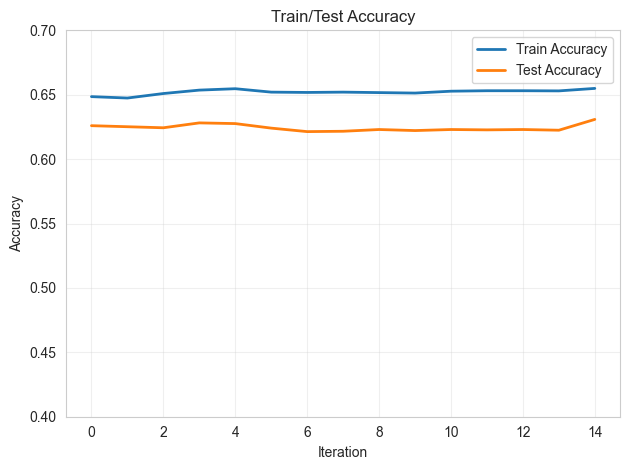

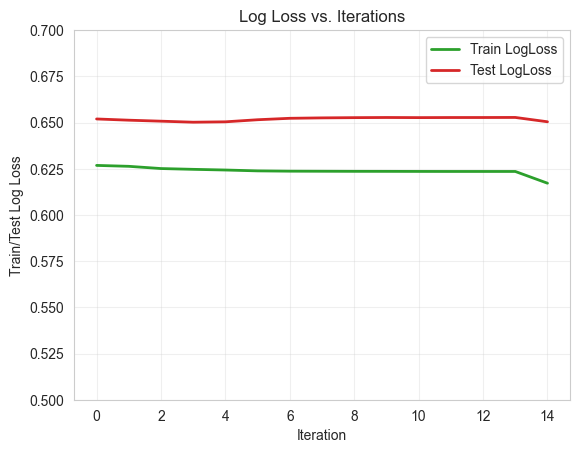

In [52]:
# --- Convert to numpy arrays for plotting ---
hist_grid = result["history"]

# convert arrays safely
iters     = np.array(hist_grid["iter"], dtype=float)
train_acc = np.array(hist_grid["train_acc"], dtype=float)
test_acc  = np.array(hist_grid["test_acc"], dtype=float)
train_ll  = np.array(hist_grid["train_logloss"], dtype=float)
test_ll   = np.array(hist_grid["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.5, 0.7)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Method 2: Bayesian Search

In [53]:
space  = [
    Real(1e-4, 1e1,   "log-uniform", name="lambda_s"),
    Real(1e-4, 1e1,   "log-uniform", name="lambda_b"),
    Real(1e-6, 1e-1, "log-uniform", name="lambda_g"),
]

all_results = []

@use_named_args(space)
def objective(lambda_s, lambda_b,lambda_g):
    print(f"Trying λs={lambda_s:.4e}, λb={lambda_b:.4e}, λg={lambda_g:.4e}")


    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        lambda_g=lambda_g,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )

    result = model.fit(
        df=df,
        split_col="split",
        split_value="train",
        test_frame=test,
        max_iter=800,
        verbose=1,
    )

    acc, logloss = model.evaluate(test)

    print(f"Accuracy: {acc:.6f}")
    print(f"Logloss: {logloss:.6f}")

    # record each step for analysis later
    all_results.append({
        "lambda_s": lambda_s,
        "lambda_b": lambda_b,
        "lambda_g": lambda_g,
        "accuracy": acc,
        "logloss": logloss,
    })

    return -acc

In [54]:
result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=50,           # number of trials (start with 25–50)
    n_initial_points=10,  # random explorations before GP fit
    random_state=42,
    acq_func="EI"         # Expected Improvement
)

Trying λs=9.6098e-01, λb=8.2637e-04, λg=7.9151e-03
Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6260 ll=0.6520
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6241 ll=0.6507
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6290 ll=0.6502


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6279 ll=0.6504
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6244 ll=0.6515
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6195 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6209 ll=0.6533
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6203 ll=0.6533
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6211 ll=0.6534
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0016] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0017] Train acc=0.6534 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0018] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0019] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0020] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6260 ll=0.6520
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6241 ll=0.6507
[0003] Train acc=0.6536 ll=0.6247 | Test acc=0.6290 ll=0.6502
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6279 ll=0.6504
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6244 ll=0.6515
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6195 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6203 ll=0.6533
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6211 ll=0.6534
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0016] T

...

[0004] Train acc=0.6544 ll=0.6243 | Test acc=0.6282 ll=0.6504
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6244 ll=0.6515
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6523 ll=0.6235 | Test acc=0.6209 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6209 ll=0.6533
[0010] Train acc=0.6524 ll=0.6235 | Test acc=0.6203 ll=0.6532
[0011] Train acc=0.6529 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6529 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6529 ll=0.6235 | Test acc=0.6211 ll=0.6533
Estimated global home‑court multiplier θ̄ = 1.4092
Final: Train acc=0.6551, logloss=0.6171
Accuracy: 0.629810
Logloss: 0.650888
Trying λs=2.1110e-02, λb=6.7818e-02, λg=5.4135e-06
Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6260 ll=0.6520
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6279 ll=0.6504
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6244 ll=0.6515
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6195 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6203 ll=0.6533
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6211 ll=0.6534
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0016] Train acc=0.6534 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0017] Train acc=0.6534 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0018] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0019] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0020] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6195 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6203 ll=0.6533
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6211 ll=0.6534
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0016] Train acc=0.6534 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0017] Train acc=0.6534 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0018] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0019] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6534
[0020] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6535
[0021] Train acc=0.6535 ll=0.6235 | Test acc=0.6217 ll=0.6535
[0022] T


Optimization completed
Best parameters: λs=8.2443e+00, λb=2.1568e-02, λg=1.9939e-02
Best accuracy: 0.630081
Best logloss: 0.650881


<Axes: >

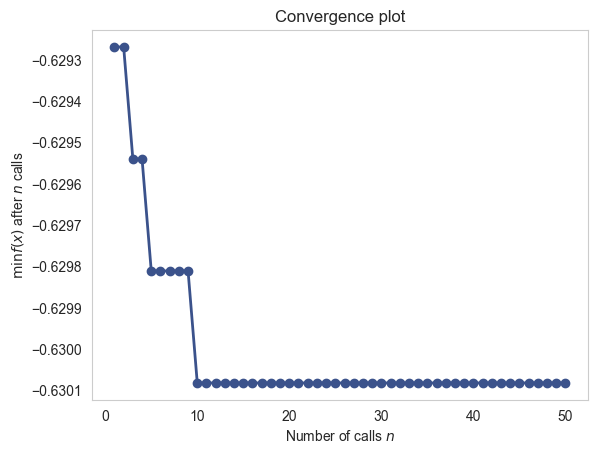

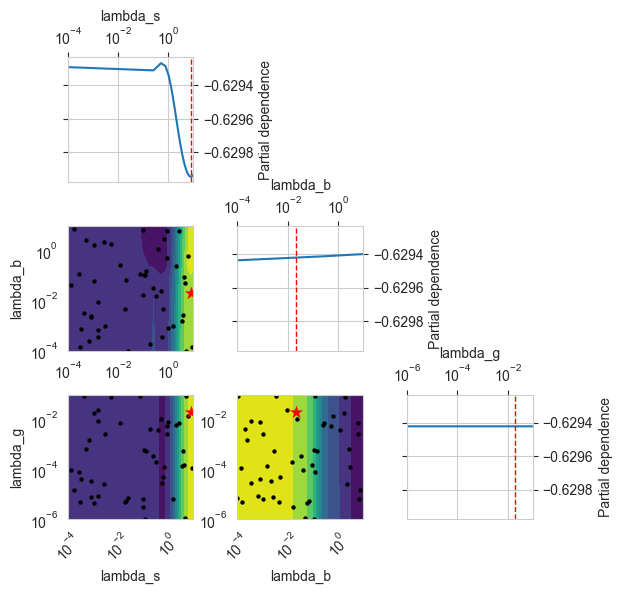

In [55]:
# best parameters found
best_lambda_s, best_lambda_b, best_lambda_g = result.x
# convert back to positive accuracy
best_acc = -result.fun
# find the matching logloss from our stored results
best_entry = min(all_results, key=lambda r: abs(r["accuracy"] - best_acc))
best_logloss = best_entry["logloss"]

print("\nOptimization completed")
print(f"Best parameters: λs={best_lambda_s:.4e}, λb={best_lambda_b:.4e}, λg={best_lambda_g:.4e}")
print(f"Best accuracy: {best_acc:.6f}")
print(f"Best logloss: {best_logloss:.6f}")

plot_convergence(result)
plot_objective(result)

In [56]:
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=1.2229e-01,
    lambda_b=1.1436e-01,
    lambda_g=1.0848e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)


result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    verbose=1,
    test_frame=test,
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6260 ll=0.6520
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6241 ll=0.6507
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6290 ll=0.6502
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6279 ll=0.6504
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6244 ll=0.6515
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6220 ll=0.6523
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6206 ll=0.6536
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6195 ll=0.6535
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6209 ll=0.6533
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6203 ll=0.6533
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6206 ll=0.6533
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6211 ll=0.6533
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6211 ll=0.6534
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6214 ll=0.6534
[0015] Tra

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



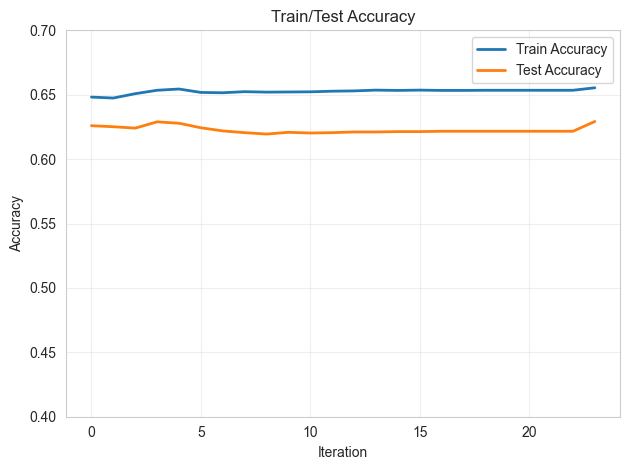

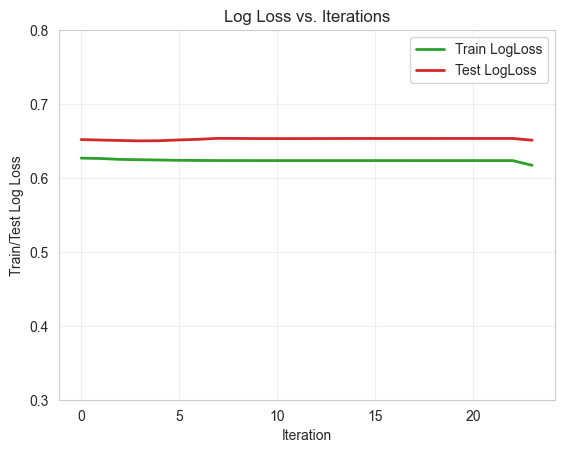

In [57]:
# --- Convert to numpy arrays for plotting ---
hist_baye = result["history"]

# convert arrays safely
iters     = np.array(hist_baye["iter"], dtype=float)
train_acc = np.array(hist_baye["train_acc"], dtype=float)
test_acc  = np.array(hist_baye["test_acc"], dtype=float)
train_ll  = np.array(hist_baye["train_logloss"], dtype=float)
test_ll   = np.array(hist_baye["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.3, 0.8)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Stratified KFold

Select Best K

In [58]:
K = 30 # number of folds
max_iter = 1200     # training iterations per fold

# storage lists
fold_results = []
df_cv = df.drop(columns=["split"])
# The target variable for stratification
y = df_cv["home_win"].values
# Create StratifiedKFold object
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)


for fold, (train_idx, test_idx) in enumerate(skf.split(df_cv, y), 1):
    print(f"\nFold {fold}/{K}")

    train = df.iloc[train_idx]
    test  = df.iloc[test_idx]

    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=1.2229e-01,
        lambda_b=1.1436e-01,
        lambda_g=1.0848e-06,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )


    result = model.fit(
        df,
        split_col="split",
        split_value="train",
        max_iter=10000,
        verbose=1,
        test_frame=test,
    )

    # Evaluate model on both folds
    train_acc, train_ll = model.evaluate(train)
    test_acc, test_ll   = model.evaluate(test)

    print(f"Fold {fold:>2}: Train acc={train_acc:.3f}, logloss={train_ll:.4f} | "
          f"Test acc={test_acc:.3f}, logloss={test_ll:.4f}")

    fold_results.append({
        "fold": fold,
        "train_acc": train_acc,
        "train_ll": train_ll,
        "test_acc": test_acc,
        "test_ll": test_ll,
    })

# Aggregate results
results_df = pd.DataFrame(fold_results)
print("\nCross‑Validation Summary")
print(results_df)

print("\nMean metrics across folds:")
print(results_df.mean(numeric_only=True).to_frame().T.round(4))


Fold 1/30
Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6304 ll=0.6288
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6304 ll=0.6280
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6327 ll=0.6284
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6213 ll=0.6269


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6349 ll=0.6269
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6281 ll=0.6276
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6281 ll=0.6283
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6236 ll=0.6285
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6259 ll=0.6284
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6259 ll=0.6282
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6259 ll=0.6282
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6281 ll=0.6281
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6304 ll=0.6281
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6304 ll=0.6282
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6304 ll=0.6282
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6304 ll=0.6283
[0016] Train acc=0.6534 ll=0.6235 | Test acc=0.6304 ll=0.6283
[0017] Train acc=0.6534 ll=0.6235 | Test acc=0.6304 ll=0.6283
[0018] Train acc=0.6535 ll=0.6235 | Test acc=0.6304 ll=0.6283
[0019] Train acc=0.6535 ll=0.6235 | Test acc=0.6304 ll=0.6283
[0020] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6054 ll=0.6445
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6145 ll=0.6430
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6168 ll=0.6401
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6281 ll=0.6380
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6281 ll=0.6365
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6281 ll=0.6349
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6213 ll=0.6344
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6168 ll=0.6345
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6190 ll=0.6347
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6213 ll=0.6348
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6213 ll=0.6349
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6190 ll=0.6350
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6168 ll=0.6351
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6190 ll=0.6351
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6213 ll=0.6351
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6236 ll=0.6351
[0016] T

...

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6591 ll=0.6201
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6523 ll=0.6191
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6500 ll=0.6179
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6636 ll=0.6159
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6659 ll=0.6148
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6705 ll=0.6139
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6705 ll=0.6138
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6636 ll=0.6151
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6636 ll=0.6139
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6636 ll=0.6144
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6636 ll=0.6145
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6636 ll=0.6146
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6636 ll=0.6146
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6636 ll=0.6147
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6636 ll=0.6147
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6614 ll=0.6147
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6409 ll=0.6452
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6341 ll=0.6439
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6432 ll=0.6420
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6523 ll=0.6409
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6545 ll=0.6405
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6545 ll=0.6398
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6523 ll=0.6394
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6455 ll=0.6389
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6568 ll=0.6387
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6568 ll=0.6387
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6568 ll=0.6387
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6568 ll=0.6386
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6568 ll=0.6386
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6568 ll=0.6384
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6568 ll=0.6384
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6545 ll=0.6384
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



Found K=13 is the best among 30 folds, Lock K=13

In [59]:
K = 13     #chosen from empirical test
max_iter = 1200

fold_results = []
df_cv = df[df["split"].isin(["train", "test"])]
y = df_cv["home_win"].values

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)


for fold, (train_idx, test_idx) in enumerate(skf.split(df_cv, y), 1):
    print(f"\nFold {fold}/{K}")

    train_df = df_cv.iloc[train_idx].copy()
    test_df  = df_cv.iloc[test_idx].copy()

    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=1.2229e-01,
        lambda_b=1.1436e-01,
        lambda_g=1.0848e-06,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )


    result = model.fit(
        df_cv,
        split_col="split",
        split_value="train",
        max_iter=10000,
        verbose=1,
        test_frame=test,
    )

    train_acc, train_ll = model.evaluate(train_df)
    test_acc, test_ll   = model.evaluate(test_df)

    fold_results.append({
        "fold": fold,
        "train_acc": train_acc,
        "train_ll": train_ll,
        "test_acc": test_acc,
        "test_ll": test_ll,
    })

    print(
        f"Fold {fold:>2}: Train acc={train_acc:.4f}, logloss={train_ll:.4f} | "
        f"Test acc={test_acc:.4f}, logloss={test_ll:.4f}"
    )

# ---- Summaries ----
results_df = pd.DataFrame(fold_results)
print("\nCross‑Validation Summary (K=12)")
print(results_df)
print("\nMean metrics across folds:")
print(results_df.mean(numeric_only=True).to_frame().T.round(4))


Fold 1/13
Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6545 ll=0.6367
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6455 ll=0.6368
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6409 ll=0.6389


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6432 ll=0.6396
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6477 ll=0.6413
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6432 ll=0.6424
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6409 ll=0.6427
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6341 ll=0.6416
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6364 ll=0.6419
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0016] Train acc=0.6534 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0017] Train acc=0.6534 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0018] Train acc=0.6535 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0019] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6545 ll=0.6367
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6455 ll=0.6368
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6409 ll=0.6389
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6432 ll=0.6396
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6477 ll=0.6413
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6432 ll=0.6424
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6409 ll=0.6427
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6341 ll=0.6416
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6364 ll=0.6419
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0016] T

...

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6545 ll=0.6367
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6455 ll=0.6368
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6409 ll=0.6389
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6432 ll=0.6396
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6477 ll=0.6413
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6432 ll=0.6424
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6409 ll=0.6427
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6341 ll=0.6416
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6364 ll=0.6419
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



[0000] Train acc=0.6482 ll=0.6268 | Test acc=0.6545 ll=0.6367
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6455 ll=0.6368
[0002] Train acc=0.6509 ll=0.6251 | Test acc=0.6409 ll=0.6389
[0003] Train acc=0.6535 ll=0.6247 | Test acc=0.6432 ll=0.6396
[0004] Train acc=0.6545 ll=0.6243 | Test acc=0.6477 ll=0.6413
[0005] Train acc=0.6518 ll=0.6238 | Test acc=0.6432 ll=0.6424
[0006] Train acc=0.6516 ll=0.6237 | Test acc=0.6409 ll=0.6427
[0007] Train acc=0.6524 ll=0.6236 | Test acc=0.6341 ll=0.6416
[0008] Train acc=0.6521 ll=0.6235 | Test acc=0.6364 ll=0.6419
[0009] Train acc=0.6522 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0010] Train acc=0.6523 ll=0.6235 | Test acc=0.6318 ll=0.6415
[0011] Train acc=0.6528 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0012] Train acc=0.6530 ll=0.6235 | Test acc=0.6318 ll=0.6414
[0013] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0014] Train acc=0.6534 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0015] Train acc=0.6536 ll=0.6235 | Test acc=0.6318 ll=0.6413
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\3705724520.py:25: UserWarning:

Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.

C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.



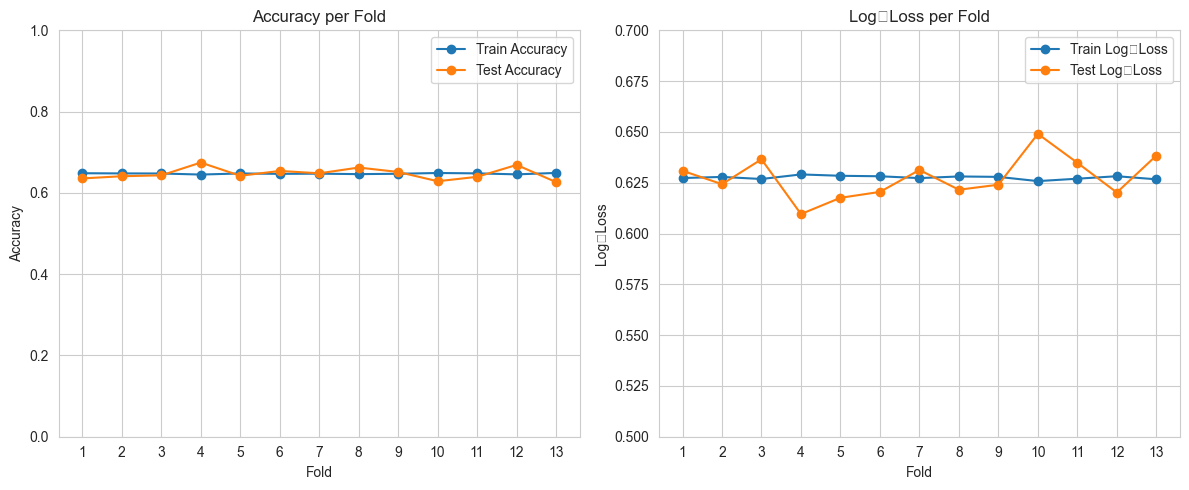


Cross‑validated accuracy (95% CI): 0.647 [0.639, 0.655]


In [60]:
# Figure setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Plot 1: Accuracy -----
axes[0].plot(results_df["fold"], results_df["train_acc"], marker="o", label="Train Accuracy")
axes[0].plot(results_df["fold"], results_df["test_acc"], marker="o", label="Test Accuracy")
axes[0].set_title("Accuracy per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylim(0.5,0.7)
axes[0].set_xticks(results_df["fold"])
axes[0].legend()
axes[0].set_ylim(0, 1)  # accuracy ranges 0-1

# ----- Plot 2: Log‑Loss -----
axes[1].plot(results_df["fold"], results_df["train_ll"], marker="o", label="Train Log‑Loss")
axes[1].plot(results_df["fold"], results_df["test_ll"], marker="o", label="Test Log‑Loss")
axes[1].set_ylim(0.5,0.7)
axes[1].set_title("Log‑Loss per Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Log‑Loss")
axes[1].set_xticks(results_df["fold"])
axes[1].legend()

plt.tight_layout()
plt.show()

mean_acc = results_df["test_acc"].mean()
std_acc = results_df["test_acc"].std()
conf_low = mean_acc - 1.96 * std_acc / (K ** 0.5)
conf_high = mean_acc + 1.96 * std_acc / (K ** 0.5)

print(f"\nCross‑validated accuracy (95% CI): {mean_acc:.3f} "
      f"[{conf_low:.3f}, {conf_high:.3f}]")

### Finalized Model

In [61]:
final_df = pd.concat([train, test], axis=0).reset_index(drop=True)
final_df.drop(["split"], axis=1, inplace=True)
final_df.head()

,season,GAME_ID,home_abbr,away_abbr,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year,Game_Type
0,2014-15,21401219,HOU,UTA,1,0.0,0,1.0,1.0,0.0,-2.8,0.0,1.842697,0.305556,2014,regular
1,2014-15,21401218,DAL,POR,1,0.0,0,1.0,1.0,0.0,-8.2,0.0,-1.917773,0.159091,2014,regular
2,2014-15,21401224,BKN,ORL,1,0.0,0,1.0,1.0,0.0,2.7,0.3,2.514658,0.159091,2014,regular
3,2014-15,21401220,MEM,IND,1,0.0,1,1.0,0.0,1.0,-8.2,-0.3,2.591931,0.386364,2014,regular
4,2014-15,21401229,GSW,DEN,1,0.0,0,1.0,1.0,0.0,10.2,0.5,13.797753,0.692619,2014,regular


In [62]:
final_model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=1.2229e-01,
    lambda_b=1.1436e-01,
    lambda_g=1.0848e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context,
    sd_context=sd_context,
)

# Fit using all combined training data
final_model.fit(
    df=final_df,
    max_iter=max_iter,
    verbose=1,
)

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6444 ll=0.6322 | Test acc=nan ll=nan
[0001] Train acc=0.6458 ll=0.6316 | Test acc=nan ll=nan
[0002] Train acc=0.6480 ll=0.6303 | Test acc=nan ll=nan
[0003] Train acc=0.6466 ll=0.6298 | Test acc=nan ll=nan
[0004] Train acc=0.6462 ll=0.6294 | Test acc=nan ll=nan
[0005] Train acc=0.6467 ll=0.6291 | Test acc=nan ll=nan
[0006] Train acc=0.6465 ll=0.6291 | Test acc=nan ll=nan
[0007] Train acc=0.6471 ll=0.6289 | Test acc=nan ll=nan
[0008] Train acc=0.6468 ll=0.6289 | Test acc=nan ll=nan
[0009] Train acc=0.6467 ll=0.6289 | Test acc=nan ll=nan
[0010] Train acc=0.6477 ll=0.6289 | Test acc=nan ll=nan
[0011] Train acc=0.6479 ll=0.6289 | Test acc=nan ll=nan
[0012] Train acc=0.6478 ll=0.6289 | Test acc=nan ll=nan
[0013] Train acc=0.6477 ll=0.6289 | Test acc=nan ll=nan
[0014] Train acc=0.6475 ll=0.6289 | Test acc=nan ll=nan
[0015] Train acc=0.6476 ll=0.6289 | Test acc=nan ll=nan
[0016] Train acc=0.6476 ll=0.6289 | Test acc

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



{'opt_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 8243.543953151895
         x: [ 3.851e-02 -1.674e-01 ...  1.273e-02  3.092e-01]
       nit: 21
       jac: [ 1.602e-02 -3.746e-03 ... -1.023e-01  1.300e-02]
      nfev: 24
      njev: 24
  hess_inv: <40x40 LbfgsInvHessProduct with dtype=float64>,
 'history': {'iter': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21],
  'train_acc': [np.float64(0.6444091149973503),
   np.float64(0.6458475282004694),
   np.float64(0.6480430009841774),
   np.float64(0.6466045877810583),
   np.float64(0.6462260579907638),
   np.float64(0.6466802937391173),
   np.float64(0.6465288818229995),
   np.float64(0.6471345294874706),
   np.float64(0.6467559996971761),
   np.float64(0.6466802937391173),
   np.float64(0.6476644711938829),
   np.float64(0.6478915890680597),
   np.float64(0.6478158831100007),

### Save Model

In [63]:
save_model(
    final_model,
    path_npz="models/btwithcovariates_fold13.npz",
    path_json="models/btwithcovariates_fold13.json",
    extra_meta={"K": K, "max_iter": max_iter},
)

Model parameters saved to models/btwithcovariates_fold13.json
Model saved successfully to models/btwithcovariates_fold13.npz


### 1.B Validation

Model loaded successfully from models/btwithcovariates_fold13.npz
Teams: 30 | Features: 4


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\3452764545.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\3452764545.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\3452764545.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

,home_abbr,away_abbr,HCA_total,theta_game,pred_prob_home_win,pred_label,home_win
13798,MEM,DAL,0.048152,1.049330,0.613474,1,1
13799,POR,LAL,0.048152,1.049330,0.390975,0,1
13800,ATL,ORL,0.048152,1.049330,0.503248,1,1
13801,MIN,UTA,0.048152,1.049330,0.837299,1,1
13802,SAC,PHX,0.048152,1.049330,0.632588,1,1
...,...,...,...,...,...,...,...
15096,MIA,WAS,0.077809,1.080916,0.781243,1,1
15097,SAS,IND,0.101365,1.106681,0.443090,0,1
15098,IND,SAS,0.048152,1.049330,0.552028,1,1
15099,MIL,ATL,0.113565,1.120265,0.627795,1,1


Evaluation Metrics on Validation Data
Accuracy : 0.6602
Log Loss : 0.6105
Precision: 0.6862
Recall   : 0.6964
F1 Score : 0.6913


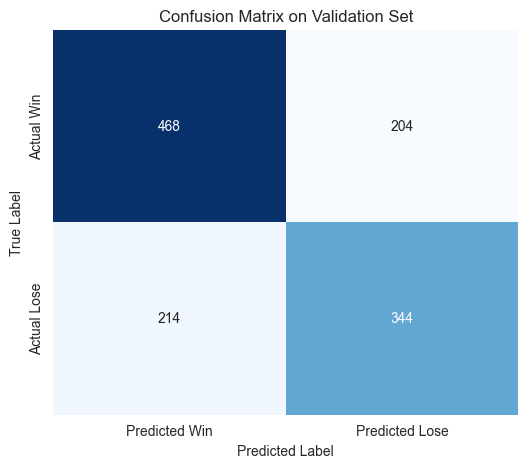

In [64]:
model = load_model("models/btwithcovariates_fold13.npz")
valid_df = df[df["split"] == "valid"]

# Standardize context columns
Z_valid = np.zeros((len(valid_df), len(model.context_cols)))
for j, col in enumerate(model.context_cols):
    Z_valid[:, j] = (valid_df[col] - model.mu_context[j]) / model.sd_context[j]
# Compute contextual home advantage for each game
valid_df["HCA_context"] = Z_valid @ model.gamma
valid_df["HCA_total"] = model.alpha_hca + Z_valid @ model.gamma
valid_df["theta_game"] = np.exp(valid_df["HCA_total"])

valid_df["pred_prob_home_win"] = model.predict_proba(valid_df)
# For classification label
valid_df["pred_label"] = (valid_df["pred_prob_home_win"] >= model.threshold).astype(int)
valid_df = valid_df[(valid_df["home_abbr"] != "NONE") & (valid_df["away_abbr"].notna())]
valid_df=valid_df[["home_abbr", "away_abbr", "HCA_total", "theta_game", "pred_prob_home_win", "pred_label","home_win"]]
display(valid_df)

valid_df.to_csv("./results/valid_result.csv", index=False)

# --- Extract prediction and true labels ---
y_true = valid_df["home_win"]
y_pred = valid_df["pred_label"]

# --- Compute evaluation metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
logloss = log_loss(y_true, valid_df["pred_prob_home_win"])

# --- Print summary ---
print("Evaluation Metrics on Validation Data")
print(f"Accuracy : {acc:.4f}")
print(f"Log Loss : {logloss:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_display = ConfusionMatrixDisplay(cm, display_labels=["Home Win (1)", "Home Lose (0)"])

# --- Visualize nicely ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Win", "Predicted Lose"],
            yticklabels=["Actual Win", "Actual Lose"])
plt.title("Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

count    1230.000000
mean        1.085706
std         0.147723
min         0.827874
25%         1.049330
50%         1.049330
75%         1.120265
max         1.610156
Name: theta_game, dtype: float64


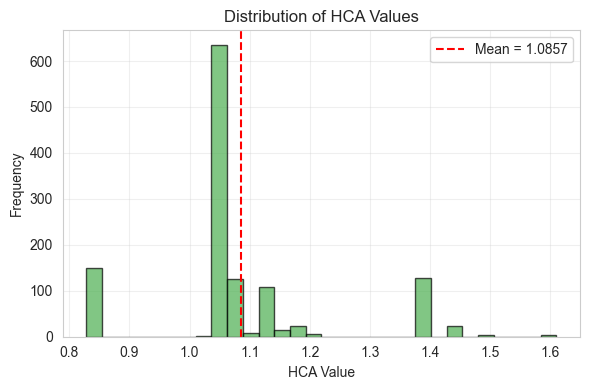

In [65]:
print(valid_df["theta_game"].describe())
HCA= valid_df["theta_game"]
plt.figure(figsize=(6, 4))
plt.hist(HCA, bins=30, color="#4CAF50", alpha=0.7, edgecolor="black")
plt.axvline(HCA.mean(), color="red", linestyle="--", label=f"Mean = {HCA.mean():.4f}")
plt.title("Distribution of HCA Values")
plt.xlabel("HCA Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
pair_summary = (
    valid_df
    .groupby(["home_abbr", "away_abbr"], as_index=False)
    .agg(
        avg_HCA=("HCA_total", "mean"),
        avg_pred_prob_home_win=("pred_prob_home_win", "mean"),
        total_home_win=("home_win", "sum"),
        total_predicted_win=("pred_label", "sum"),
        total_games=("pred_label", "count")
    )
)

# Complementary counts
pair_summary["total_predicted_lose"] = (
    pair_summary["total_games"] - pair_summary["total_predicted_win"]
)

pair_summary["pred_label"] = (
    pair_summary["avg_pred_prob_home_win"] > 0.5
).astype(int)

pair_summary.to_csv("results/1vs29_summary.csv",index=False)

## Model Comparison

### 1. Map team abbreviations to numeric indices

In [67]:
df_valid = df[df["split"] == "valid"]
teams = sorted(set(df_valid["home_abbr"]) | set(df_valid["away_abbr"]))
team_to_idx = {team: i for i, team in enumerate(teams)}
n_teams = len(teams)

print(f"{n_teams} unique teams found.")

30 unique teams found.


### 2. Prepare win–loss comparisons

In [68]:
comparisons = [
    (team_to_idx[row.home_abbr], team_to_idx[row.away_abbr])
    if row.home_win == 1 else
    (team_to_idx[row.away_abbr], team_to_idx[row.home_abbr])
    for _, row in df_valid.iterrows()
]

### 3. Fit the Bradley–Terry model

3.1 Without Home‑Court Advantage

In [69]:
bt_nohca = choix.ilsr_pairwise(n_items=n_teams, data=comparisons, alpha=0.01)

3.2 With HCA

In [70]:
home_flags = np.array([1 if row.home_win==1 else -1 for _, row in df_valid.iterrows()])

# Pairwise comparisons with context vector “home=+1 / −1”
data_with_context = []
for (i, j), flag in zip(comparisons, home_flags):
    data_with_context.append((i, j, np.array([flag], dtype=float)))

# Initialize parameter
theta_all = np.zeros(n_teams + 1)

# gradient-ascent on log-likelihood
def contextual_fit(data, n_items, step_size=1e-3, n_iter=5000):
    theta = np.zeros(n_items + 1)
    for _ in range(n_iter):
        grad = np.zeros_like(theta)
        for winner, loser, x in data:
            logit = (theta[winner] - theta[loser]) + np.dot(theta[n_items:], x)
            p = expit(logit)
            grad[winner] += (1 - p)
            grad[loser]  -= (1 - p)
            grad[n_items:] += (1 - p) * x
        theta += step_size * grad
    return theta

theta_all = contextual_fit(data_with_context, n_teams)
bt_hca = theta_all[:-1]
log_theta = theta_all[-1]
theta = np.exp(log_theta)
print(f"Estimated home‑court multiplier θ = {theta:.4f}")

Estimated home‑court multiplier θ = 1.2529


### Model Performance

In [71]:
def predict_prob(df, ability, theta=1):
    probs = []
    for r in df.itertuples(index=False):
        i = team_to_idx[r.home_abbr]
        j = team_to_idx[r.away_abbr]
        p = (theta * np.exp(ability[i])) / (theta * np.exp(ability[i]) + np.exp(ability[j]))
        probs.append(p)
    return np.array(probs)

p_nohca = predict_prob(df_valid, bt_nohca)
p_hca   = predict_prob(df_valid, bt_hca, theta)

ll_nohca = log_loss(df_valid.home_win, p_nohca)
ll_hca   = log_loss(df_valid.home_win, p_hca)
acc_nohca = accuracy_score(df_valid.home_win, p_nohca > 0.5)
acc_hca   = accuracy_score(df_valid.home_win, p_hca > 0.5)

print(f"No HCA → logloss  {ll_nohca:.4f}, acc {acc_nohca:.4f}")
print(f"With HCA → logloss {ll_hca:.4f}, acc {acc_hca:.4f}")

No HCA → logloss  0.5844, acc 0.7016
With HCA → logloss 0.5793, acc 0.7114


In [72]:
# --- Compute predictions for both models ---
p_nohca = predict_prob(df_valid, bt_nohca)
p_hca   = predict_prob(df_valid, bt_hca, theta)

# --- Predicted classes (0/1) ---
y_hat_nohca = (p_nohca >= 0.5).astype(int)
y_hat_hca   = (p_hca >= 0.5).astype(int)

# --- Performance metrics ---
ll_nohca = log_loss(df_valid.home_win, p_nohca)
ll_hca   = log_loss(df_valid.home_win, p_hca)
acc_nohca = accuracy_score(df_valid.home_win, y_hat_nohca)
acc_hca   = accuracy_score(df_valid.home_win, y_hat_hca)

# --- Combine outputs into a readable DataFrame ---
df_pred = df_valid.copy()
df_pred = df_pred.assign(
    prob_nohca=p_nohca,
    prob_hca=p_hca,
    pred_nohca=y_hat_nohca,
    pred_hca=y_hat_hca
)

# Show first few predictions with actual outcome and model results
cols_to_show = [
    "home_abbr", "away_abbr", "home_win",
    "prob_nohca", "prob_hca", "pred_nohca", "pred_hca"
]
print("\nSample predictions:")
print(df_pred[cols_to_show].to_string(index=False))


Sample predictions:
home_abbr away_abbr  home_win  prob_nohca  prob_hca  pred_nohca  pred_hca
      MEM       DAL         1    0.607759  0.662590           1         1
      POR       LAL         1    0.323828  0.369685           0         0
      ATL       ORL         1    0.495902  0.553225           0         1
      MIN       UTA         1    0.858749  0.888785           1         1
      SAC       PHX         1    0.546171  0.602893           1         1
      MIL       DET         1    0.546691  0.601451           1         1
      SAS       TOR         1    0.568362  0.624805           1         1
      BOS       CHA         1    0.913897  0.934523           1         1
      MIA       WAS         0    0.749037  0.791403           1         1
      GSW       LAC         0    0.473659  0.528033           0         1
      CLE       IND         0    0.699842  0.753459           1         1
      BKN       NYK         0    0.210110  0.243378           0         0
      HOU       D

In [73]:
print(df[df["split"] == "train"][model.context_cols].mean())
print(df[df["split"] == "valid"][model.context_cols].mean())
val_theta = np.exp(model.alpha_hca + HCA.mean())
print(f"Validation home‑court multiplier θ_val = {val_theta:.3f}")

home_b2b          0.137894
away_b2b          0.249125
home_rest_days    1.193630
away_rest_days    1.033297
rest_diff         0.160333
dtype: float64
home_b2b          0.179675
away_b2b          0.186179
home_rest_days    1.161789
away_rest_days    1.111382
rest_diff         0.050407
dtype: float64
Validation home‑court multiplier θ_val = 3.273
